# Maximum likelihood Estimation (MLE)
based on http://python-for-signal-processing.blogspot.com/2012/10/maximum-likelihood-estimation-maximum.html
## Simulate coin flipping
- [Bernoulli distribution](https://en.wikipedia.org/wiki/Bernoulli_distribution) 
is the probability distribution of a random variable which takes the value 1 with probability $p$ and the value 0 with probability $q = 1 - p$
- [scipy.stats.bernoulli](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.bernoulli.html)

In [37]:
import numpy as np
from scipy.stats import bernoulli 

np.random.seed(123456789)

p_true = 1/2 # this is the value we will try to estimate from the observed data
fp = bernoulli(p_true) #bernoulli(0.5)

def sample(n=10):
    """
    simulate coin flipping
    """
    return fp.rvs(n) # flip it n times

#xs = sample(5)
#xs = sample(10)
#xs = sample(20) # generate some samples
#xs = sample(50)
xs = sample(100)
print(xs)

[1 1 1 1 0 1 1 0 1 1 1 1 1 0 0 0 0 0 0 1 1 1 0 0 1 1 0 0 1 0 1 0 0 1 1 1 1
 0 0 1 1 1 0 1 1 0 1 0 1 1 1 0 0 1 1 0 1 0 0 0 1 0 1 0 0 0 0 0 0 0 1 1 1 1
 0 1 0 1 1 0 0 0 1 0 0 0 1 0 0 0 0 1 0 0 0 1 1 0 0 1]


## Find maximum of Bernoulli distribution
Single experiment
$$\phi(x) = p ^ {x} * (1 - p) ^ { 1 - x }$$
Series of experiments
$$\mathcal{L}(p|x) = \prod_{i=1}^{n} p^{x_{i}}*(p-1)^{1-x_{i}}$$
### Hints
- [sympy.diff()](http://docs.sympy.org/dev/modules/core.html#sympy.core.function.diff)
- [sympy.expand()](http://docs.sympy.org/dev/modules/core.html#sympy.core.function.expand)
- [sympy.expand_log()](http://docs.sympy.org/dev/modules/core.html#sympy.core.function.expand_log)
- [sympy.solve()](http://docs.sympy.org/dev/modules/core.html#sympy.core.function.solve)
- [sympy.symbols()](http://docs.sympy.org/dev/modules/core.html#symbols)
- [sympy gotchas](http://docs.sympy.org/dev/tutorial/gotchas.html)

In [38]:
import sympy
from sympy.abc import x

p = sympy.symbols('p', positive=True)
phi = p ** x * (1 - p) ** (1 - x)

#L=p^H (1-p)^T
L = np.prod([phi.subs(x, i) for i in xs]) # objective function to maximize

#log_L = log(L)
log_L = sympy.expand_log(sympy.log(L))

sol = sympy.solve(sympy.diff(log_L, p), p)[0]

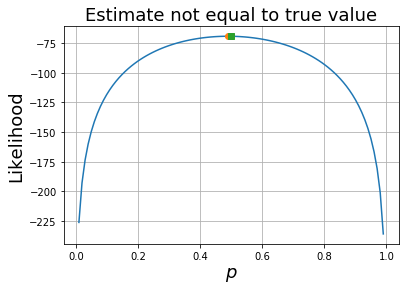

In [39]:
import matplotlib.pyplot as plt

x_space = np.linspace(1/100, 1, 100, endpoint=False)

plt.plot(x_space,
         list(map(sympy.lambdify(p, log_L, 'numpy'), x_space)),
         sol,
         log_L.subs(p, sol),
         'o',
         p_true,
         log_L.subs(p, p_true),
         's',
        )
plt.xlabel('$p$', fontsize=18)
plt.ylabel('Likelihood', fontsize=18)
plt.title('Estimate not equal to true value', fontsize=18)
plt.grid(True)
plt.show()

## Empirically examine the behavior of the maximum likelihood estimator 
- [evalf()](http://docs.sympy.org/dev/modules/core.html#module-sympy.core.evalf)

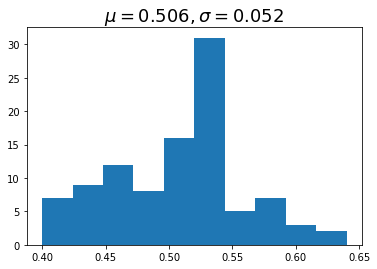

In [42]:
def estimator_gen(niter=10, ns=100):
    """
    generate data to estimate distribution of maximum likelihood estimator'
    """
    x = sympy.symbols('x', real=True)
    phi = p**x*(1-p)**(1-x)
    for i in range(niter):
        xs = sample(ns) # generate some samples from the experiment
        L = np.prod([phi.subs(x,i) for i in xs]) # objective function to maximize
        log_L = sympy.expand_log(sympy.log(L)) 
        sol = sympy.solve(sympy.diff(log_L, p), p)[0]
        yield float(sol.evalf())
    
entries = list(estimator_gen(100)) # this may take awhile, depending on how much data you want to generate
plt.hist(entries) # histogram of maximum likelihood estimator
plt.title('$\mu={:3.3f},\sigma={:3.3f}$'.format(np.mean(entries), np.std(entries)), fontsize=18)
plt.show()

## Let's do MAP estimation now
If our data looks like this:

In [43]:
X_arr = np.ones(10)
X_arr

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1.])

## Choosing a prior: Beta distribution

Our MLE will simply be 0. But this is probably not true (as we might have been unlucky with the samples that we get. We may have a prior belief that the true parameter value should be around 0.5. Thus, we can set a prior distribution on the true parameter value (note that the parameter in question is the probability of coin toss. 

In [44]:
alpha = beta = 2
#theta = 0.7#this is true parameter
n = 50
#X_arr = np.random.choice([0, 1], p=[1-theta, theta], size=n)
X_arr = np.ones(n)
print(X_arr)

[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1.]


In [45]:
beta_arr = np.asarray([[alpha+sum(X_arr[:i+1]), beta+(i+1-sum(X_arr[:i+1]))] for i in range(X_arr.size)])
beta_arr = np.insert(beta_arr, 0, [alpha, beta], 0)

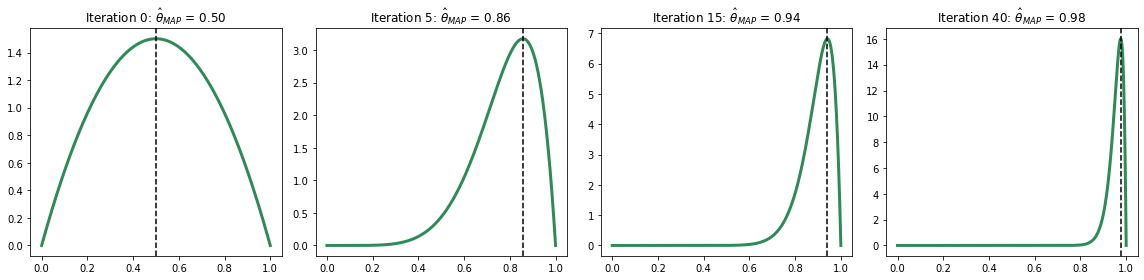

In [46]:
import scipy as sp

beta_X = np.linspace(0, 1, 1000)

my_color = '#2E8B57'
fig, ax_arr = plt.subplots(ncols=4, figsize=(16,4), sharex=True)
#for i, iter_ in enumerate([0, 1, 2, 3,]):
for i, iter_ in enumerate([0, 5, 15, 40,]):
    ax = ax_arr[i]
    a, b = beta_arr[iter_]
    beta_Y = sp.stats.beta.pdf(x=beta_X, a=a, b=b)
    ax.plot(beta_X, beta_Y, color=my_color, linewidth=3)
    if a > 1 and b > 1:
        mode = (a-1)/(a+b-2)
    else:
        mode = a/(a+b)
    ax.axvline(x=mode, linestyle='--', color='k')
    ax.set_title('Iteration %d: $\hat{\\theta}_{MAP}$ = %.2f'%(iter_, mode))
fig.tight_layout()